<a href="https://colab.research.google.com/github/jeeva477/NLP/blob/main/nlp_project_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# Install required packages
!pip install -q nltk kagglehub

# Import libraries
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import kagglehub
import os

from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

# Download NLTK resources
nltk.download('stopwords')
nltk.download('vader_lexicon')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [11]:
path = kagglehub.dataset_download('datafiniti/consumer-reviews-of-amazon-products')
print('Dataset downloaded to:', path)

# Load the CSV file
file_path = os.path.join(path, 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv')
df = pd.read_csv(file_path)

Using Colab cache for faster access to the 'consumer-reviews-of-amazon-products' dataset.
Dataset downloaded to: /kaggle/input/consumer-reviews-of-amazon-products


In [12]:
df = df[['reviews.text', 'reviews.rating']].dropna()
df.rename(columns={
    'reviews.text': 'Review Content',
    'reviews.rating': 'Rating'
}, inplace=True)

# Use first 1000 reviews for faster execution
df = df.head(1000)

print('\\nFirst 5 Reviews:')
print(df.head())

print('\\nDataset Information:')
print(df.info())

\nFirst 5 Reviews:
                                      Review Content  Rating
0  I thought it would be as big as small paper bu...       3
1  This kindle is light and easy to use especiall...       5
2  Didnt know how much i'd use a kindle so went f...       4
3  I am 100 happy with my purchase. I caught it o...       5
4  Solid entry level Kindle. Great for kids. Gift...       5
\nDataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Review Content  1000 non-null   object
 1   Rating          1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB
None


In [13]:
# Convert to lowercase
df['Review Content'] = df['Review Content'].astype(str).str.lower()

# Tokenization
tokenizer = RegexpTokenizer(r'\\w+')
df['Tokens'] = df['Review Content'].apply(tokenizer.tokenize)

# Remove stopwords
stop_words = set(stopwords.words('english'))

df['Clean_Text'] = df['Tokens'].apply(
    lambda words: [word for word in words if word not in stop_words]
)

# Join tokens back into text
df['Processed_Text'] = df['Clean_Text'].apply(lambda words: ' '.join(words))



In [14]:
sia = SentimentIntensityAnalyzer()

def classify_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Processed_Text'].apply(classify_sentiment)


In [15]:

print('\\nSample Predictions:')
print(df[['Review Content', 'Rating', 'Sentiment']].head())



\nSample Predictions:
                                      Review Content  Rating Sentiment
0  i thought it would be as big as small paper bu...       3   Neutral
1  this kindle is light and easy to use especiall...       5   Neutral
2  didnt know how much i'd use a kindle so went f...       4   Neutral
3  i am 100 happy with my purchase. i caught it o...       5   Neutral
4  solid entry level kindle. great for kids. gift...       5   Neutral


In [16]:
sentiment_counts = df['Sentiment'].value_counts()

print('\\nSentiment Counts:')
print(sentiment_counts)


\nSentiment Counts:
Sentiment
Neutral    1000
Name: count, dtype: int64


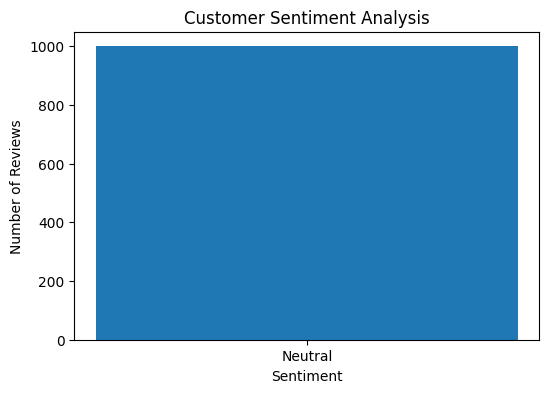

In [17]:
plt.figure(figsize=(6,4))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title('Customer Sentiment Analysis')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()


In [19]:
negative_reviews = df[df['Sentiment'] == 'Negative']

print('\\nTop 10 Negative Reviews:')
print(negative_reviews['Review Content'].head(10))


\nTop 10 Negative Reviews:
Series([], Name: Review Content, dtype: object)


In [20]:
total_reviews = len(df)
positive_reviews = (df['Sentiment'] == 'Positive').sum()
negative_reviews_count = (df['Sentiment'] == 'Negative').sum()
neutral_reviews = (df['Sentiment'] == 'Neutral').sum()

print('\\nBusiness Insights')
print('--------------------------------')
print(f'Total Reviews      : {total_reviews}')
print(f'Positive Reviews   : {positive_reviews}')
print(f'Negative Reviews   : {negative_reviews_count}')
print(f'Neutral Reviews    : {neutral_reviews}')

positive_percentage = (positive_reviews / total_reviews) * 100
negative_percentage = (negative_reviews_count / total_reviews) * 100

print(f'Positive %         : {positive_percentage:.2f}%')
print(f'Negative %         : {negative_percentage:.2f}%')

if negative_reviews_count > 0:
    print('\\nSuggestions:')
    print('- Improve product quality')
    print('- Improve packaging')
    print('- Improve delivery experience')
    print('- Strengthen customer support')
    print('- Analyze recurring complaints from negative reviews')
else:
    print('\\nCustomers are mostly satisfied with the product.')


\nBusiness Insights
--------------------------------
Total Reviews      : 1000
Positive Reviews   : 0
Negative Reviews   : 0
Neutral Reviews    : 1000
Positive %         : 0.00%
Negative %         : 0.00%
\nCustomers are mostly satisfied with the product.


In [21]:
output_file = '/content/amazon_sentiment_results.csv'
df.to_csv(output_file, index=False)

print(f'\\nSentiment analysis completed successfully!')
print(f'Results saved to: {output_file}')

\nSentiment analysis completed successfully!
Results saved to: /content/amazon_sentiment_results.csv
